In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder #Trasforma feature qualitative in feature quantitative
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier #Multi layer Perceptron

In [3]:
data = pd.read_csv("./titanic.csv")

## Trasforma un campo da stringhe in numeri! 

In [4]:
sex_label_encoder = LabelEncoder()
data["Sex_numeric"] = sex_label_encoder.fit_transform(data['Sex']) #è un po' come un enum
data.head(10)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Sex_numeric
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,0
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,0
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,1
5,0,3,Mr. James Moran,male,27.0,0,0,8.4583,1
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,1
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,1
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,0
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,0


In [5]:
sex_label_encoder.classes_ #Quì è dove si salva l'array di feature qualitative

array(['female', 'male'], dtype=object)

In [6]:
sex_label_encoder.transform(["male","female"])

array([1, 0])

In [7]:
sex_label_encoder.inverse_transform([0, 1, 1, 0, 0])

array(['female', 'male', 'male', 'female', 'female'], dtype=object)

In [8]:
data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Sex_numeric
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,0
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,0
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,1


In [9]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare', 'Sex_numeric'],
      dtype='object')

## Machine learning

In [10]:
output = ["Survived"]
features = ['Pclass', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare', 'Sex_numeric'] #feature engineering, abbiamo tolto le feature che non ci servono

In [11]:
X = data[features].to_numpy()
X

array([[ 3.    , 22.    ,  1.    ,  0.    ,  7.25  ,  1.    ],
       [ 1.    , 38.    ,  1.    ,  0.    , 71.2833,  0.    ],
       [ 3.    , 26.    ,  0.    ,  0.    ,  7.925 ,  0.    ],
       ...,
       [ 3.    ,  7.    ,  1.    ,  2.    , 23.45  ,  0.    ],
       [ 1.    , 26.    ,  0.    ,  0.    , 30.    ,  1.    ],
       [ 3.    , 32.    ,  0.    ,  0.    ,  7.75  ,  1.    ]],
      shape=(887, 6))

In [12]:
y = data[output].to_numpy()

## Normalizzazione (o standardizzazione)

Vogliamo che tutte le feature abbiano:
* valor medio 0
* e deviazione standard 1

In [13]:
age = data["Age"].to_numpy()
#Così ho un array di media 0!
age_zero_mean = age - np.mean(age)
np.mean(age_zero_mean)

np.float64(1.1535304842103092e-15)

In [14]:
age_zero_mean_one_std = age_zero_mean / np.std(age_zero_mean)

In [15]:
np.std(age_zero_mean_one_std)

np.float64(1.0)

In [16]:
np.mean(age_zero_mean_one_std)

np.float64(2.4031885087714774e-17)

## Dobbiamo normalizzare tutte le feature, per reti neurali è obbligatorio

Il comando di seguito fa le media 0 e la deviazione 1

In [17]:
scaler = StandardScaler()
#Mi normalizza tutto!
X_norm = scaler.fit_transform(X)

### Creiamo e addestriamo la rete neurale

Le variabili di seguito servono per dividere in due il dataset in allenamento e test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, random_state=42, test_size=0.3)

In [19]:
X_train[0]

array([-1.56127657,  1.59619127, -0.47585568, -0.4749808 , -0.03628696,
        0.74026551])

### Comando di creazione della rete neurale

In [30]:
neural_network = MLPClassifier(hidden_layer_sizes=(4,3), max_iter=1000)

Comando di addestramento della mia rete neurale

In [31]:
neural_network.fit(X_train, y_train.reshape(-1))

,hidden_layer_sizes,"(4, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [32]:
neural_network.score(X_test, y_test)

0.7902621722846442

## Accuratezza rete neurale

l'accuratezza è la percentuale di casi indovinati correttamente; non dipende dal fatto che un caso sia Survived oppure no

In [33]:
neural_network.score(X_train, y_train) #accuratezza sui dati di training

0.8467741935483871

In [34]:
neural_network.score(X_test, y_test) #accuratezza sui dai di test

0.7902621722846442

### Mettiamo la rete neurale alla prova con un passeggero mai visto

In [37]:
features

['Pclass',
 'Age',
 'Siblings/Spouses Aboard',
 'Parents/Children Aboard',
 'Fare',
 'Sex_numeric']

In [38]:
johndoe = np.array([[2, 12, 0, 1, 70, 1]])
johndoe

array([[ 2, 12,  0,  1, 70,  1]])

In [40]:
johndoe_normalizzata = scaler.transform(johndoe)
johndoe_normalizzata

array([[-0.36537647, -1.2378851 , -0.47585568,  0.76416028,  0.75761953,
         0.74026551]])

In [44]:
neural_network.predict(johndoe_normalizzata) #Secondo lui sopravvive

array([1])

In [45]:
neural_network.predict_proba(johndoe_normalizzata) #Quante probabilità ha di sopravviere o meno

array([[0.36346729, 0.63653271]])

## Salvare il modello di rete neurale soddisfacente

Salviamo su un file binario l'istanza neural_network addestrata. 

In [50]:
from joblib import dump 
#Il file contiene la rete neurale addestrata con tutti i suoi metodi

In [49]:
dump(neural_network, 'rete_neurale_titanic.dump')

['rete_neurale_titanic.dump']

### Fare a casa:
(Abbiamo trasformato i dati della feature Age, ma **non abbiamo modificato la loro distribuzione statistica**)
Creare una figura con 2 istogrammi:

1. istogramma della feature originale Age;
2. Istogramma della feature normalizzata

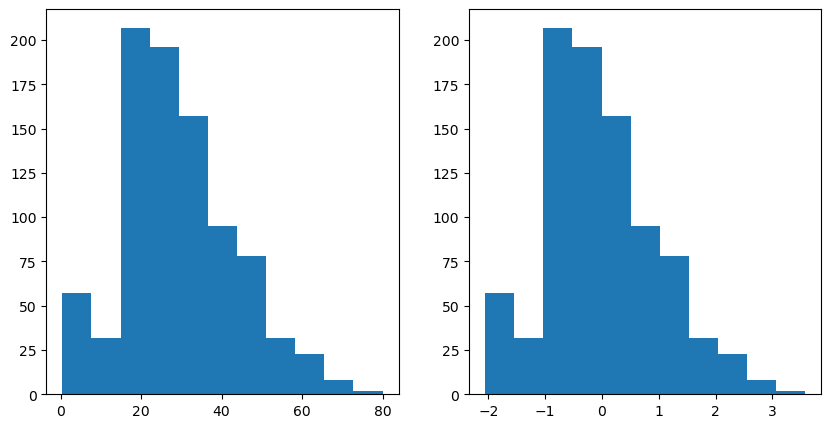

In [78]:
fig,axs = plt.subplots(nrows = 1, ncols = 2, figsize=(10,5))
axs[0].hist(age, bins = 11)
axs[1].hist(age_zero_mean_one_std, bins = 11)
plt.show()